# Q1

(a) Convolution function

In [126]:
import numpy as np
import matplotlib.pyplot as plt

def conv2d(image, kernel, stride=1, padding=0, activation="relu"):
    if padding > 0:
      width,height,channels=image.shape

      padded_image=np.zeros(width +2*padding,height+2*padding,channels)

      padded_image[padding:padding + width, padding:padding + height, :]=image
      image = padded_image

    w_out = (image.shape[0] - kernel.shape[0]) // stride + 1
    h_out = (image.shape[1] - kernel.shape[1]) // stride + 1

    output = np.zeros((w_out,h_out))

    for i in range(0, w_out):
      for j in range(0, h_out):
        region = image[i * stride:i * stride + kernel.shape[0], j * stride:j * stride + kernel.shape[1], :]
        output[i, j] = np.sum(region * kernel[:, :, :])

    if activation == "sigmoid":
      return 1 / (1 + np.exp(-output))
    elif activation == "tanh":
      return np.tanh(output)
    elif activation == "relu":
      return np.maximum(0, output)
    else:
      alpha = 0.1
      return np.where(output > 0,output, alpha * output)


In [127]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

x=unpickle("/content/data_batch_1")

labels = x[b'labels']
data = x[b'data']

Image = data[0].reshape(3,32,32)
Image = Image.transpose(2,1, 0)

Input Image 


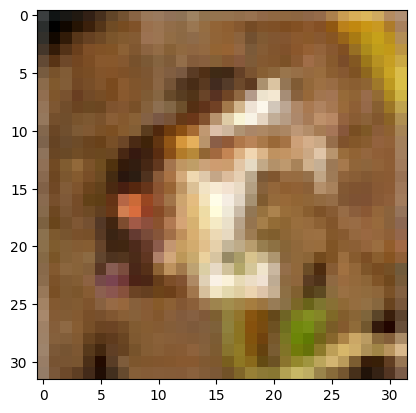

Output Image


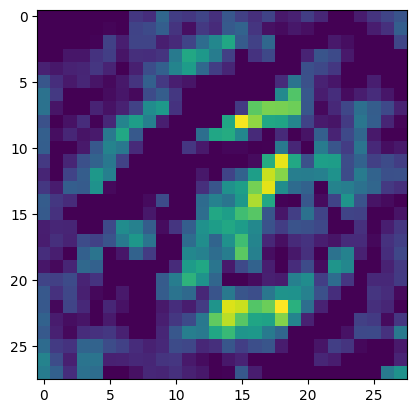

Kernel


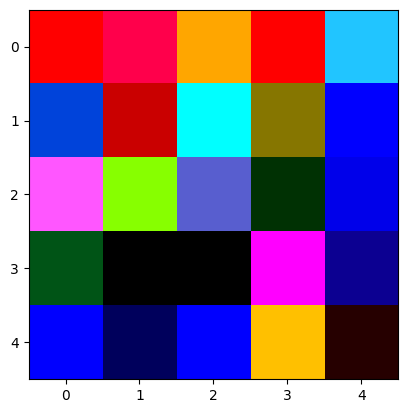

In [129]:
def Genratekernels(w,h,channels):
  return np.random.randn(w,h,channels)

kernel=Genratekernels(5,5,3)

Output=conv2d(Image, kernel, stride=1, padding=0, activation="relu")

print("Input Image ")
plt.imshow(Image)
plt.show()

print("Output Image")
plt.imshow(Output)
plt.show()

print("Kernel")
plt.imshow(kernel)
plt.show()



(b) Pooling function

In [130]:
def Pooling(activation_map,pool_size=2,stride=2,pooling_type="max"):
  w_out = (activation_map.shape[0] - pool_size) // stride + 1
  h_out = (activation_map.shape[1] - pool_size) // stride + 1

  pooled_output=np.zeros((w_out,h_out))

  for i in range(0, w_out):
    for j in range(0, h_out):
      region = activation_map[i * stride:i * stride + pool_size, j * stride:j * stride + pool_size]

      if pooling_type == "max":
        pooled_output[i, j] = np.max(region)
      elif pooling_type == "average":
        pooled_output[i, j] = np.mean(region)

  return pooled_output

Activation Map 


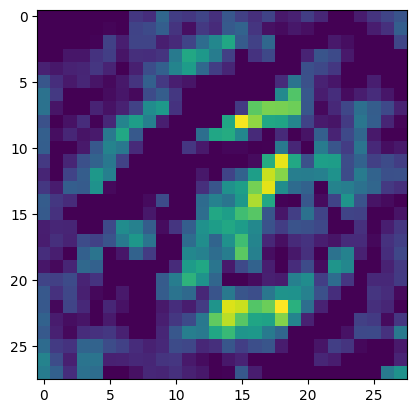

Pooled Output


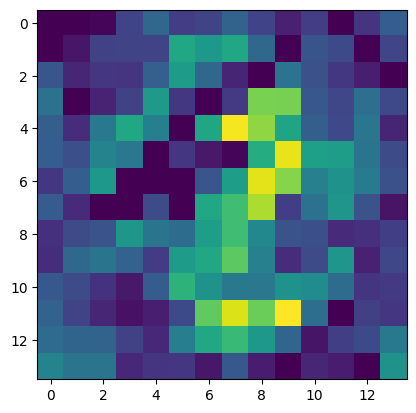

In [131]:
pooled_output=Pooling(Output,pool_size=2,stride=2,pooling_type="max")

print("Activation Map ")
plt.imshow(Output)
plt.show()

print("Pooled Output")
plt.imshow(pooled_output)
plt.show()


(c) Convolution layer function

In [134]:
def Convlayerfun(activation_map,kernels,stride=1,padding=0,activation="relu"):
  output_vol=[]

  for i in range(kernels.shape[-1]):
    kernel=kernels[i,:,:,:]
    conv_output=conv2d(activation_map,kernel,stride,padding,activation)
    output_vol.append(conv_output)

  output_vol=np.array(output_vol)
  return output_vol


Input Image 


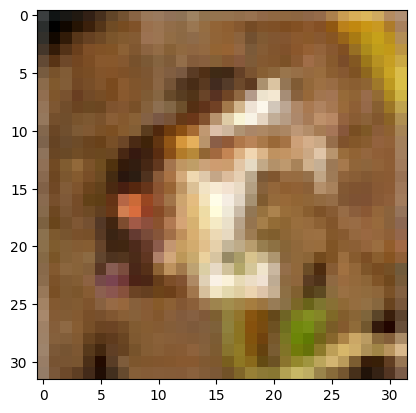

Output Image


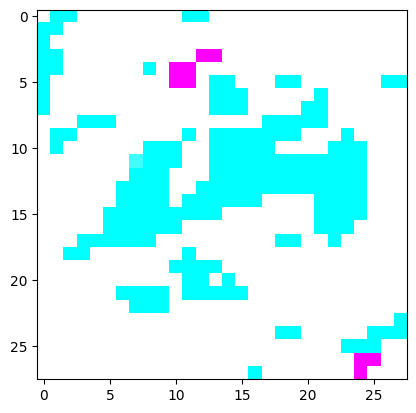

Kernel 1


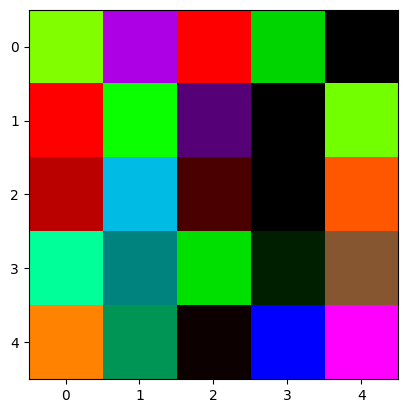

Kernel 2


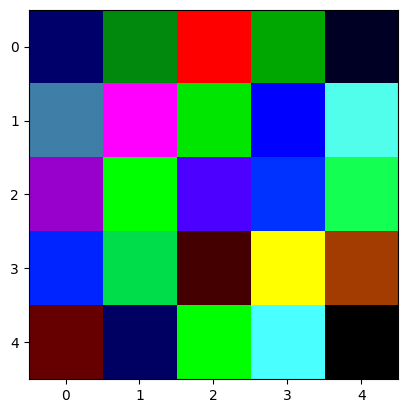

Kernel


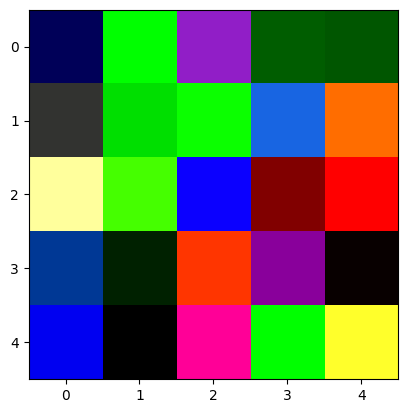

In [149]:
kernels=[]
for i in range(3):
  kernel=Genratekernels(5,5,3)
  kernels.append(kernel)

kernels=np.array(kernels)

output_vol=Convlayerfun(Image,kernels,stride=1,padding=0,activation="relu")

print("Input Image ")
plt.imshow(Image)
plt.show()

print("Output Image")
plt.imshow(output_vol.transpose(2,1,0))
plt.show()

print("Kernel 1")
plt.imshow(kernels[0])
plt.show()

print("Kernel 2")
plt.imshow(kernels[1])
plt.show()

print("Kernel")
plt.imshow(kernels[2])
plt.show()



(d) Pooling Layer function

Activation_map 


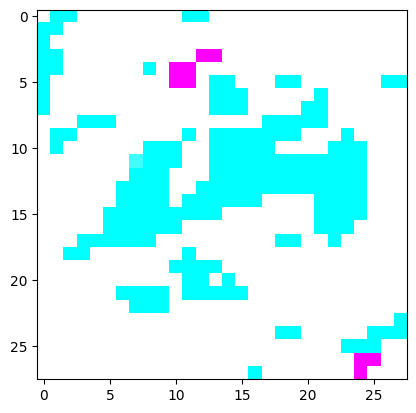

Output Image


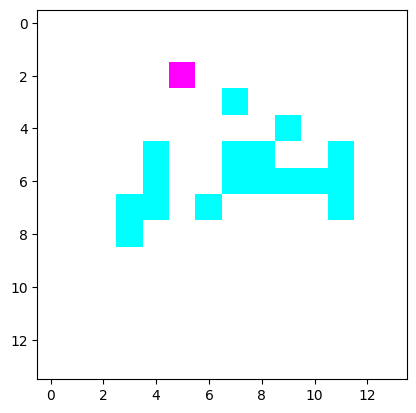

In [154]:
def poolinglayerfun(activation_map,pool_size=2,stride=2,pooling_type="max"):
  a=[]
  for i in range(activation_map.shape[0]):
    a.append(Pooling(activation_map[i,:,:],pool_size,stride,pooling_type))
  return np.array(a)

output=poolinglayerfun(output_vol,pool_size=2,stride=2,pooling_type="max")

print("Activation_map ")
plt.imshow(output_vol.transpose(2,1,0))
plt.show()

print("Output Image")
plt.imshow(output.transpose(2,1,0))
plt.show()


(e) Flattening (unraveling) function

In [155]:
def Flatten(activation_map, output_size):
    flattened_vector = activation_map.reshape(-1)
    weight_matrix = np.random.rand(flattened_vector.shape[0], output_size)
    output_vector = np.dot(flattened_vector, weight_matrix)
    return output_vector


(f) Multilayer Perceptron (MLP) function (Fully Connected)

In [156]:
def softmax(inp):
  inp=np.array(inp)
  outp=[]
  for i in range(len(inp)):

    ma=np.max(inp[i])
    for j in range(len(inp[0])):
      inp[i][j]=inp[i][j]-ma

    out=[]
    sum0=0
    for j in range(len(inp[0])):
      a=np.exp(inp[i][j])
      sum0=sum0+np.exp(inp[i][j])

    for k in range(len(inp[0])):
      a=np.exp(inp[i][k])/sum0
      out.append(a)

    outp.append(out)

  outp=np.array(outp)
  return outp

In [162]:
def MLP(input,num_hidden_layer,hidden_layer_size,output_layer_size,activation):
  layers=[input.size] + [hidden_layer_size]*num_hidden_layer +[output_layer_size]
  weights=[np.random.randn(layers[i],layers[i+1]) for i in range(len(layers)-1)]

  #forward
  A=input
  for i in range(num_hidden_layer+1):
    Z=np.dot(A,weights[i])

    if activation == "sigmoid":
      A= 1 / (1 + np.exp(-Z))
    elif activation == "tanh":
      A= np.tanh(Z)
    elif activation == "relu":
      A= np.maximum(0, Z)
    else:
      alpha = 0.1
      A= np.where(Z > 0,Z, alpha * Z)

  #output_withSoft=softmax(A)
  output_withoutSoft=A
  return output_withoutSoft#,output_withSoft

In [163]:
def feedforwardpath(Image):
  kernels=[]
  for i in range(4):
    kernel=Genratekernels(5,5,3)
    kernels.append(kernel)

  kernels=np.array(kernels)

  output_vol=Convlayerfun(Image,kernels,stride=1,padding=0,activation="relu")

  output=poolinglayerfun(output_vol,pool_size=2,stride=2,pooling_type="max")


  kernels=[]
  for i in range(4):
    kernel=Genratekernels(5,5,3)
    kernels.append(kernel)

  kernels=np.array(kernels)

  output_vol=Convlayerfun(Image,kernels,stride=1,padding=0,activation="relu")

  output=poolinglayerfun(output_vol,pool_size=2,stride=2,pooling_type="max")

  x=Flatten(output, 256)

  num_hidden_layer=1
  hidden_layer_size=49
  output_layer_size=10
  activation="relu"
  x1=MLP(x,num_hidden_layer,hidden_layer_size,output_layer_size,activation)

  return x1


In [164]:
x1=feedforwardpath(Image)
print(x1)

[ 687938.81356047 1056582.75924276       0.               0.
 7736449.00944221 4504018.78614444 7242233.67046605 2980129.97188312
       0.         4519129.05338968]


# Q2

1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(in_channels=3, out_channels=4, kernel_size=5, stride=1, padding=2)

    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv2 = nn.Conv2d(in_channels=4, out_channels=4, kernel_size=5, stride=1, padding=2)

    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.flatten = nn.Flatten()

    self.fc1 = nn.Linear(4 * 8 * 8, 49)
    self.fc2 = nn.Linear(49, 10)

  def forward(self, x):
    x = self.pool1(nn.relu(self.conv1(x)))
    x = self.pool2(F.relu(self.conv2(x)))
    x = self.flatten(x)
    x = nn.relu(self.fc1(x))
    x = self.fc2(x)
    return x

torch.manual_seed(42)
model=CNN()


In [2]:
Loss_fn=nn.CrossEntropyLoss()

In [ ]:
def train(optimizer,X):
  torch.manual_seed(42)

  epochs=10
  train_loss=0

  for i in range(len(epochs)):
    y_pred=model(X)

    loss=Loss_fn(y_pred,y)
    train_loss+=loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


(a) Vanilla SGD

In [ ]:
sgd_optimizer = optim.SGD(model.parameters(), lr=0.001)
train(sgd_optimizer)

(b) Momentum

In [ ]:
momentum_optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
train(momentum_optimizer)

(c) RMSProp

In [ ]:
rmsprop_optimizer = optim.RMSprop(model.parameters(), lr=0.001, alpha=0.9)
train(rmsprop_optimizer)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=4, kernel_size=5, stride=1, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(4 * 8 * 8, 49)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(49, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        bottleneck = self.flatten(x)
        x = F.relu(self.fc1(bottleneck))
        x = self.dropout(x)  # Apply dropout
        x = self.fc2(x)
        return x, bottleneck